# Main vs Undirected Correlation

Pearson correlation matrix (18×18 undirected) fed to same CNN vs directed GC.

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, PREICTAL_SEC, SPH_SEC,
    POSTICTAL_EXCL_SEC, EXCLUDED_PATIENTS, RANDOM_SEED, RESULTS_DIR
)
from summary_parser import parse_all_summaries
from data_loader    import load_edf
from preprocessing  import bandpass_filter, segment_signal, label_windows
from metrics        import evaluate_predictions
np.random.seed(RANDOM_SEED)
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
# Cell 1 — Parse
all_seizures = parse_all_summaries(DATA_ROOT)
print(f'Parsed {len(all_seizures)} patient entries.')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [3]:
# Cell 2 — Pearson matrix extraction
def pearson_matrix(window):
    """window: (n_channels, n_samples) → (n_channels, n_channels) Pearson R"""
    return np.corrcoef(window).astype(np.float32)

corr_patient_data = {}
patients = sorted([p for p in os.listdir(DATA_ROOT)
                   if os.path.isdir(os.path.join(DATA_ROOT, p))
                   and p.startswith('chb') and p not in EXCLUDED_PATIENTS])

for patient_id in patients:
    file_seizure_map = all_seizures.get(patient_id, {})
    if not file_seizure_map:
        continue
    print(f'\n{"─"*55}\nPatient: {patient_id}')
    all_X, all_y = [], []
    for filename in sorted(file_seizure_map):
        seizures = file_seizure_map[filename]
        if not seizures: continue
        edf_path = os.path.join(DATA_ROOT, patient_id, filename)
        if not os.path.exists(edf_path): continue
        try:
            signal, fs = load_edf(edf_path)
        except Exception: continue
        filtered  = bandpass_filter(signal)
        windows   = segment_signal(filtered)
        n_samples = filtered.shape[1]
        labels    = label_windows(n_samples, seizures)
        valid = labels != -1; windows = windows[valid]; labels = labels[valid]
        if (labels == 1).sum() == 0: continue
        matrices = np.array([pearson_matrix(w) for w in windows])
        all_X.append(matrices); all_y.append(labels)
        print(f'  [OK] {filename}  pre={(labels==1).sum()}  int={(labels==0).sum()}')
    if not all_X: continue
    X = np.concatenate(all_X); y = np.concatenate(all_y)
    corr_patient_data[patient_id] = (X, y)
    print(f'  Total: {len(y)} windows')

patient_ids = sorted(corr_patient_data.keys())
print(f'\nCorrelation data ready. Patients: {len(corr_patient_data)}')


───────────────────────────────────────────────────────
Patient: chb01
  [OK] chb01_03.edf  pre=148  int=146
    [LABEL] Seizure at 1467s: preictal window out of bounds (would start at -333s) — skipping preictal label.
    [LABEL] Seizure at 1732s: preictal window out of bounds (would start at -68s) — skipping preictal label.
    [LABEL] Seizure at 1015s: preictal window out of bounds (would start at -785s) — skipping preictal label.
    [LABEL] Seizure at 1720s: preictal window out of bounds (would start at -80s) — skipping preictal label.
    [LABEL] Seizure at 327s: preictal window out of bounds (would start at -1473s) — skipping preictal label.
  [OK] chb01_26.edf  pre=148  int=33
  Total: 475 windows

───────────────────────────────────────────────────────
Patient: chb02
  [OK] chb02_16+.edf  pre=148  int=144
    [LABEL] Seizure at 130s: preictal window out of bounds (would start at -1670s) — skipping preictal label.
  [OK] chb02_19.edf  pre=148  int=183
  Total: 623 windows

───

In [4]:
# Cell 3 — CNN (same architecture as main)
class GCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class CorrCNN(nn.Module):
    def __init__(self, n_ch=18, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            flat = self.features(torch.zeros(1,1,n_ch,n_ch)).numel()
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(flat,256), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(256,1), nn.Sigmoid()
        )
    def forward(self, x): return self.classifier(self.features(x))

print(f'CorrCNN ready.')

CorrCNN ready.


In [5]:
# Cell 4 — Training utilities
MAX_EPOCHS=50; PATIENCE=10; BATCH_SIZE=64; LR=1e-3; VAL_FRAC=0.15

def train_corr(X_tr, y_tr, X_va, y_va):
    n_pos=max(int((y_tr==1).sum()),1); n_neg=max(int((y_tr==0).sum()),1)
    pw=float(min(n_neg/n_pos,50.0))
    model=CorrCNN(N_CHANNELS).to(DEVICE)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    tr_dl=DataLoader(GCDataset(X_tr,y_tr),batch_size=BATCH_SIZE,shuffle=True)
    va_dl=DataLoader(GCDataset(X_va,y_va),batch_size=BATCH_SIZE)
    best_val,best_wts,p_ctr=float('inf'),None,0
    for epoch in range(1,MAX_EPOCHS+1):
        model.train()
        for xb,yb in tr_dl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            p=model(xb).squeeze(1)
            loss=-(yb*torch.log(p+1e-8)*pw+(1-yb)*torch.log(1-p+1e-8)).mean()
            opt.zero_grad();loss.backward();opt.step()
        model.eval();va_loss=0.0
        with torch.no_grad():
            for xb,yb in va_dl:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                p=model(xb).squeeze(1)
                va_loss+=(-(yb*torch.log(p+1e-8)*pw+(1-yb)*torch.log(1-p+1e-8)).mean()).item()*len(yb)
        va_loss/=len(va_dl.dataset)
        if epoch%5==0: print(f'  Epoch {epoch}/{MAX_EPOCHS}  val={va_loss:.4f}')
        if va_loss<best_val:
            best_val=va_loss;best_wts={k:v.cpu().clone() for k,v in model.state_dict().items()};p_ctr=0
        else:
            p_ctr+=1
            if p_ctr>=PATIENCE: print(f'  Early stop @{epoch}');break
    model.load_state_dict(best_wts);return model

def predict_corr(model,X):
    model.eval()
    dl=DataLoader(GCDataset(X,np.zeros(len(X))),batch_size=BATCH_SIZE)
    out=[]
    with torch.no_grad():
        for xb,_ in dl: out.append(model(xb.to(DEVICE)).squeeze(1).cpu().numpy())
    return np.concatenate(out)

print('Training utilities ready.')

Training utilities ready.


In [6]:
# Cell 5 — LOPO
corr_lopo_results={}
n_folds=len(patient_ids)
print('='*60)
print(f'Undirected Correlation CNN LOPO  ({n_folds} folds) | device: {DEVICE}')
print('='*60)

for fold_idx,test_pid in enumerate(patient_ids,1):
    print(f'\n[Fold {fold_idx}/{n_folds}]  Test: {test_pid}')
    X_pool=np.concatenate([corr_patient_data[p][0] for p in patient_ids if p!=test_pid])
    y_pool=np.concatenate([corr_patient_data[p][1] for p in patient_ids if p!=test_pid])
    tr_idx,va_idx=train_test_split(np.arange(len(y_pool)),test_size=VAL_FRAC,
                                    random_state=RANDOM_SEED,stratify=y_pool)
    model=train_corr(X_pool[tr_idx],y_pool[tr_idx],X_pool[va_idx],y_pool[va_idx])
    scores=predict_corr(model,corr_patient_data[test_pid][0])
    y_test=corr_patient_data[test_pid][1]
    metrics=evaluate_predictions(y_test,scores,threshold=0.5,patient_id=test_pid)
    corr_lopo_results[test_pid]=metrics
    print(f'  AUC={metrics["auc"]:.3f}  Sens={metrics["sensitivity"]:.3f}  '
          f'Spec={metrics["specificity"]:.3f}  FPR/h={metrics["fpr_per_hour"]:.1f}')

print('\nCorrelation LOPO complete.')

Undirected Correlation CNN LOPO  (21 folds) | device: cpu

[Fold 1/21]  Test: chb01
  Epoch 5/50  val=0.6324
  Epoch 10/50  val=0.5592
  Epoch 15/50  val=0.5252
  Epoch 20/50  val=0.5314
  Epoch 25/50  val=0.4995
  Epoch 30/50  val=0.5096
  Epoch 35/50  val=0.4945
  Epoch 40/50  val=0.5018
  Epoch 45/50  val=0.5044
  Epoch 50/50  val=0.5119
  AUC=0.470  Sens=0.230  Spec=0.776  FPR/h=80.4

[Fold 2/21]  Test: chb02
  Epoch 5/50  val=0.6553
  Epoch 10/50  val=0.5605
  Epoch 15/50  val=0.5315
  Epoch 20/50  val=0.5411
  Epoch 25/50  val=0.5277
  Epoch 30/50  val=0.5189
  Early stop @31
  AUC=0.472  Sens=0.220  Spec=0.768  FPR/h=83.7

[Fold 3/21]  Test: chb03
  Epoch 5/50  val=0.6535
  Epoch 10/50  val=0.6106
  Epoch 15/50  val=0.5550
  Epoch 20/50  val=0.5578
  Epoch 25/50  val=0.5310
  Epoch 30/50  val=0.5138
  Early stop @33
  AUC=0.524  Sens=0.622  Spec=0.435  FPR/h=203.6

[Fold 4/21]  Test: chb04
  Epoch 5/50  val=0.6221
  Epoch 10/50  val=0.5473
  Epoch 15/50  val=0.5187
  Epoch 20/50

=== Undirected Correlation CNN LOPO ===
patient   auc  auc_pr  sensitivity  specificity    f1  balanced_accuracy  fpr_per_hour
  chb01 0.470   0.630        0.230        0.776 0.337              0.503        80.447
  chb02 0.472   0.458        0.220        0.768 0.297              0.494        83.670
  chb03 0.524   0.671        0.622        0.435 0.656              0.528       203.551
  chb04 0.403   0.118        0.145        0.749 0.112              0.447        90.366
  chb05 0.482   0.646        0.131        0.904 0.221              0.517        34.422
  chb06 0.501   0.159        0.443        0.537 0.229              0.490       166.726
  chb07 0.492   0.151        0.405        0.583 0.216              0.494       150.193
  chb08 0.501   0.585        0.466        0.559 0.522              0.512       158.804
  chb09 0.481   0.190        0.534        0.454 0.297              0.494       196.701
  chb10 0.539   0.265        0.503        0.581 0.373              0.542       150.688
  c

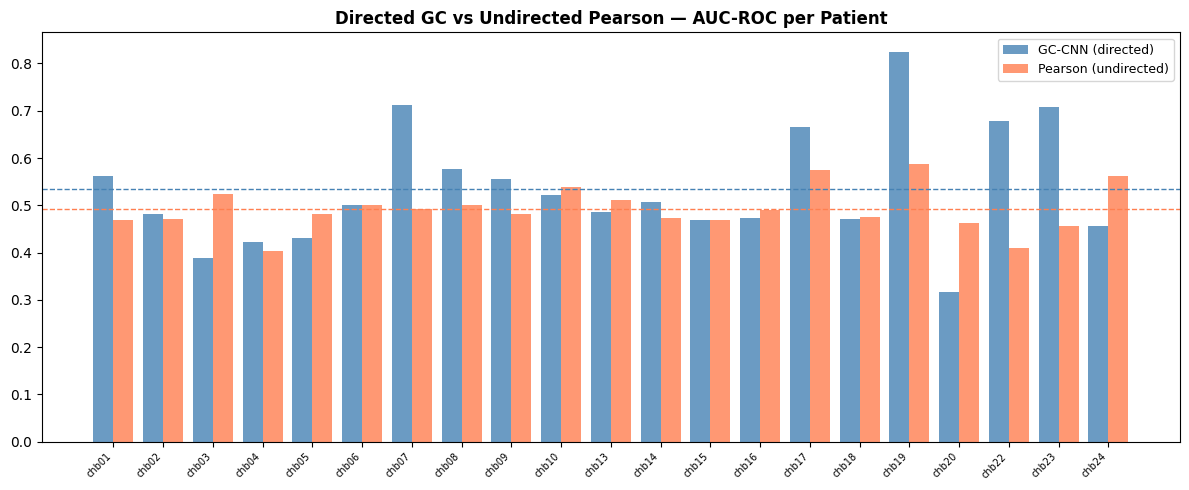

Done.


In [7]:
# Cell 6 — Save & plot
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity', 'f1', 'balanced_accuracy', 'fpr_per_hour']

rows=[{'patient':pid,**{k:corr_lopo_results[pid][k] for k in METRIC_KEYS}} for pid in patient_ids]
corr_df=pd.DataFrame(rows)
corr_df=pd.concat([corr_df,
    pd.DataFrame([{'patient':'MEAN',**{k:round(corr_df[k].mean(),4) for k in METRIC_KEYS}}]),
    pd.DataFrame([{'patient':'STD', **{k:round(corr_df[k].std(), 4) for k in METRIC_KEYS}}])
],ignore_index=True)
print('=== Undirected Correlation CNN LOPO ===')
print(corr_df.to_string(index=False,float_format='{:.3f}'.format))
os.makedirs(RESULTS_DIR,exist_ok=True)
corr_df.to_csv(os.path.join(RESULTS_DIR,'lopo_undirected_correlation.csv'),index=False)

gc_csv=os.path.join(RESULTS_DIR,'lopo_results.csv')
if os.path.exists(gc_csv):
    gc_df=pd.read_csv(gc_csv)
    pid_col=[c for c in gc_df.columns if 'patient' in c.lower()][0]
    gc_df=gc_df.rename(columns={pid_col:'patient'})
    gc_df=gc_df[~gc_df['patient'].isin(['MEAN','STD'])].reset_index(drop=True)
    corr_df2=corr_df[~corr_df['patient'].isin(['MEAN','STD'])].reset_index(drop=True)
    auc_col='auc' if 'auc' in gc_df.columns else gc_df.columns[1]
    x=np.arange(len(patient_ids))
    fig,ax=plt.subplots(figsize=(12,5))
    ax.bar(x-0.2,gc_df[auc_col].values,  0.4,label='GC-CNN (directed)',  color='steelblue',alpha=0.8)
    ax.bar(x+0.2,corr_df2['auc'].values, 0.4,label='Pearson (undirected)',color='coral',alpha=0.8)
    ax.axhline(gc_df[auc_col].mean(),  color='steelblue',linestyle='--',lw=1)
    ax.axhline(corr_df2['auc'].mean(), color='coral',linestyle='--',lw=1)
    ax.set_xticks(x);ax.set_xticklabels(patient_ids,rotation=45,ha='right',fontsize=7)
    ax.set_title('Directed GC vs Undirected Pearson — AUC-ROC per Patient',fontsize=12,fontweight='bold')
    ax.legend(fontsize=9);plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,'comparison_gc_vs_correlation.png'),dpi=150,bbox_inches='tight')
    plt.show()
print('Done.')